In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf

In [2]:
def analyze_knife_edge(
    filename,
    columns=None,
    start_row=None,
    end_row=None,
    sheet_name=0,
    x_column=None,
    signal_column=None,
    signal_sign=1,
    sep="\t",
    plot=True,
):
    """Read knife-edge scan data from Excel or text, fit the derivative profile, and plot results.

    Excel example: columns="A:B", start_row=115, end_row=143.
    Text example: x_column="X", signal_column="Photocurrent".
    """
    filename_str = str(filename)
    suffix = filename_str.lower().rsplit(".", 1)[-1]

    if suffix in ["xlsx", "xls"]:
        if columns is None or start_row is None or end_row is None:
            raise ValueError("Excel files require columns, start_row, and end_row")
        if start_row < 1:
            raise ValueError("start_row must be 1 or larger, matching Excel row numbers")
        if end_row < start_row:
            raise ValueError("end_row must be greater than or equal to start_row")

        df = pd.read_excel(
            filename,
            sheet_name=sheet_name,
            usecols=columns,
            skiprows=start_row - 1,
            nrows=end_row - start_row + 1,
            header=None,
        )
        x = df.iloc[:, 0].to_numpy(dtype=float)
        signal = df.iloc[:, 1].to_numpy(dtype=float)

    elif suffix in ["txt", "csv", "dat"]:
        with open(filename, "r") as f:
            lines = f.readlines()

        header_row = next(
            (i for i, line in enumerate(lines) if line.startswith("Time of Day")),
            0,
        )
        df = pd.read_csv(filename, sep=sep, skiprows=header_row)

        if x_column is None or signal_column is None:
            if isinstance(columns, (list, tuple)) and len(columns) == 2:
                x_column, signal_column = columns
            else:
                raise ValueError("Text files require x_column and signal_column, or columns=(x_column, signal_column)")

        x = df[x_column].to_numpy(dtype=float)
        signal = signal_sign * df[signal_column].to_numpy(dtype=float)

    else:
        raise ValueError(f"Unsupported file type: .{suffix}")

    idx = np.argsort(x)
    x = x[idx]
    signal = signal[idx]

    derivative = np.gradient(signal, x)
    profile = np.abs(derivative)

    def gaussian(x, A, x0, sigma, offset):
        return A * np.exp(-(x - x0) ** 2 / (2 * sigma ** 2)) + offset

    p0 = [
        np.max(profile) - np.min(profile),
        x[np.argmax(profile)],
        (np.max(x) - np.min(x)) / 10,
        np.min(profile),
    ]

    popt, pcov = curve_fit(gaussian, x, profile, p0=p0)
    perr = np.sqrt(np.diag(pcov))

    A_fit, x0_fit, sigma_fit, offset_fit = popt
    A_err, x0_err, sigma_err, offset_err = perr

    fwhm_factor = 2 * np.sqrt(2 * np.log(2))
    fwhm = fwhm_factor * abs(sigma_fit)
    fwhm_err = fwhm_factor * sigma_err

    residual = profile - gaussian(x, *popt)
    ss_res = np.sum(residual**2)
    ss_tot = np.sum((profile - np.mean(profile))**2)
    r_squared = 1 - ss_res / ss_tot

    print("===== Gaussian Fit Result =====")
    print(f"Amplitude A = {A_fit:.6g} +/- {A_err:.2g}")
    print(f"Center x0   = {x0_fit:.6g} +/- {x0_err:.2g}")
    print(f"Sigma       = {abs(sigma_fit):.6g} +/- {sigma_err:.2g}")
    print(f"Offset      = {offset_fit:.6g} +/- {offset_err:.2g}")
    print(f"FWHM        = {fwhm:.6g} +/- {fwhm_err:.2g}")
    print(f"R^2 = {r_squared:.4f}")

    x_fit = np.linspace(np.min(x), np.max(x), 1000)
    profile_fit = gaussian(x_fit, *popt)

    if plot:
        plt.figure(figsize=(7, 5))
        plt.plot(x, signal, "o", markersize=4, label="Raw knife-edge data")
        plt.xlabel("Knife-edge position")
        plt.ylabel("Signal")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7, 5))
        plt.plot(x, profile, "o", markersize=4, label="Derivative profile")
        plt.plot(x_fit, profile_fit, "-", linewidth=2, label="Gaussian fit")
        plt.axvline(x0_fit, linestyle="--", label="Center")
        plt.xlabel("Knife-edge position")
        plt.ylabel("|dSignal/dx|")
        plt.title(f"Beam profile from knife-edge\nFWHM = {fwhm:.4g}")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7, 5))
        plt.plot(x, residual, "o", markersize=4, label="Residuals")
        plt.xlabel("Knife-edge position")
        plt.ylabel("Residual (Data - Fit)")
        plt.legend()
        plt.tight_layout()
        plt.show()


def analyze_knife_edge_erf(
    filename,
    columns=None,
    start_row=None,
    end_row=None,
    sheet_name=0,
    x_column=None,
    signal_column=None,
    signal_sign=1,
    sep="\t",
    plot=True,
):
    """Fit the raw knife-edge signal with an erf step instead of differentiating first."""
    filename_str = str(filename)
    suffix = filename_str.lower().rsplit(".", 1)[-1]

    if suffix in ["xlsx", "xls"]:
        if columns is None or start_row is None or end_row is None:
            raise ValueError("Excel files require columns, start_row, and end_row")
        df = pd.read_excel(
            filename,
            sheet_name=sheet_name,
            usecols=columns,
            skiprows=start_row - 1,
            nrows=end_row - start_row + 1,
            header=None,
        )
        x = df.iloc[:, 0].to_numpy(dtype=float)
        signal = signal_sign * df.iloc[:, 1].to_numpy(dtype=float)

    elif suffix in ["txt", "csv", "dat"]:
        with open(filename, "r") as f:
            lines = f.readlines()

        header_row = next(
            (i for i, line in enumerate(lines) if line.startswith("Time of Day")),
            0,
        )
        df = pd.read_csv(filename, sep=sep, skiprows=header_row)

        if x_column is None or signal_column is None:
            if isinstance(columns, (list, tuple)) and len(columns) == 2:
                x_column, signal_column = columns
            else:
                raise ValueError("Text files require x_column and signal_column, or columns=(x_column, signal_column)")

        x = df[x_column].to_numpy(dtype=float)
        signal = signal_sign * df[signal_column].to_numpy(dtype=float)

    else:
        raise ValueError(f"Unsupported file type: .{suffix}")

    idx = np.argsort(x)
    x = x[idx]
    signal = signal[idx]

    def erf_step(x, offset, height, x0, sigma):
        return offset + 0.5 * height * (1 + erf((x - x0) / (np.sqrt(2) * sigma)))

    left_level = np.median(signal[: max(3, len(signal) // 10)])
    right_level = np.median(signal[-max(3, len(signal) // 10) :])
    height0 = right_level - left_level
    half_level = left_level + 0.5 * height0
    x0_0 = x[np.argmin(np.abs(signal - half_level))]
    sigma0 = (np.max(x) - np.min(x)) / 10
    p0 = [left_level, height0, x0_0, sigma0]

    popt, pcov = curve_fit(erf_step, x, signal, p0=p0, maxfev=10000)
    perr = np.sqrt(np.diag(pcov))

    offset_fit, height_fit, x0_fit, sigma_fit = popt
    offset_err, height_err, x0_err, sigma_err = perr

    fwhm_factor = 2 * np.sqrt(2 * np.log(2))
    fwhm = fwhm_factor * abs(sigma_fit)
    fwhm_err = fwhm_factor * sigma_err

    residual = signal - erf_step(x, *popt)
    ss_res = np.sum(residual**2)
    ss_tot = np.sum((signal - np.mean(signal))**2)
    r_squared = 1 - ss_res / ss_tot

    print("===== Erf Fit Result =====")
    print(f"Offset      = {offset_fit:.6g} +/- {offset_err:.2g}")
    print(f"Height      = {height_fit:.6g} +/- {height_err:.2g}")
    print(f"Center x0   = {x0_fit:.6g} +/- {x0_err:.2g}")
    print(f"Sigma       = {abs(sigma_fit):.6g} +/- {sigma_err:.2g}")
    print(f"FWHM        = {fwhm:.6g} +/- {fwhm_err:.2g}")
    print(f"R^2 = {r_squared:.4f}")

    x_fit = np.linspace(np.min(x), np.max(x), 1000)
    signal_fit = erf_step(x_fit, *popt)
    profile_fit = np.abs(height_fit) / (np.sqrt(2 * np.pi) * abs(sigma_fit)) * np.exp(
        -(x_fit - x0_fit) ** 2 / (2 * sigma_fit**2)
    )

    if plot:
        plt.figure(figsize=(7, 5))
        plt.plot(x, signal, "o", markersize=4, label="Raw knife-edge data")
        plt.plot(x_fit, signal_fit, "-", linewidth=2, label="Erf fit")
        plt.axvline(x0_fit, linestyle="--", label="Center")
        plt.xlabel("Knife-edge position")
        plt.ylabel("Signal")
        plt.title(f"Knife-edge erf fit\nFWHM = {fwhm:.4g}")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7, 5))
        plt.plot(x_fit, profile_fit, "-", linewidth=2, label="Beam profile from erf fit")
        plt.axvline(x0_fit, linestyle="--", label="Center")
        plt.xlabel("Knife-edge position")
        plt.ylabel("|dSignal/dx|")
        plt.title(f"Beam profile inferred from erf fit\nFWHM = {fwhm:.4g}")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7, 5))
        plt.plot(x, residual, "o", markersize=4, label="Residuals")
        plt.axhline(0, color="k", linewidth=1)
        plt.xlabel("Knife-edge position")
        plt.ylabel("Residual (Data - Fit)")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "offset": offset_fit,
        "height": height_fit,
        "center": x0_fit,
        "sigma": abs(sigma_fit),
        "fwhm": fwhm,
        "r_squared": r_squared,
    }


# Excel example:
# analyze_knife_edge(
#     "C:/Users/26250/Downloads/515 pump knife edge scan.xlsx",
#     columns="A:B",
#     start_row=115,
#     end_row=143,
# )

# Text example:
# analyze_knife_edge(
#     "C:/Users/26250/Desktop/SigScan1986.txt",
#     x_column="X",
#     signal_column="Integrated Photo AI",
#     signal_sign=-1,
# )


===== Gaussian Fit Result =====
Amplitude A = 4932.9 +/- 1e+02
Center x0   = 2.56725 +/- 0.0012
Sigma       = 0.054283 +/- 0.0014
Offset      = 112.132 +/- 46
FWHM        = 0.127827 +/- 0.0033
R^2 = 0.9910


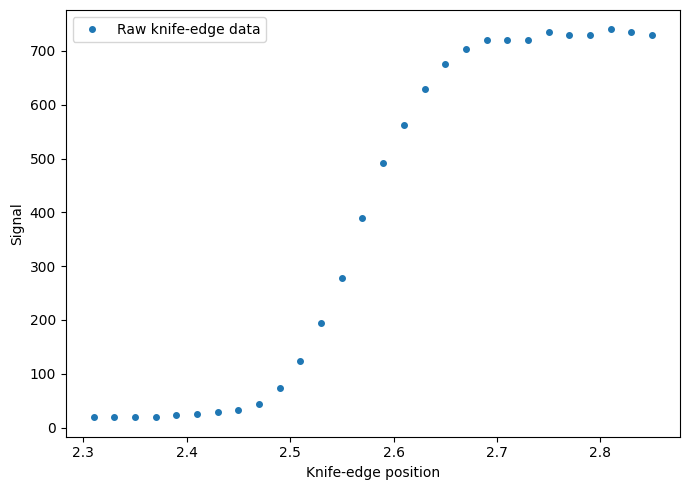

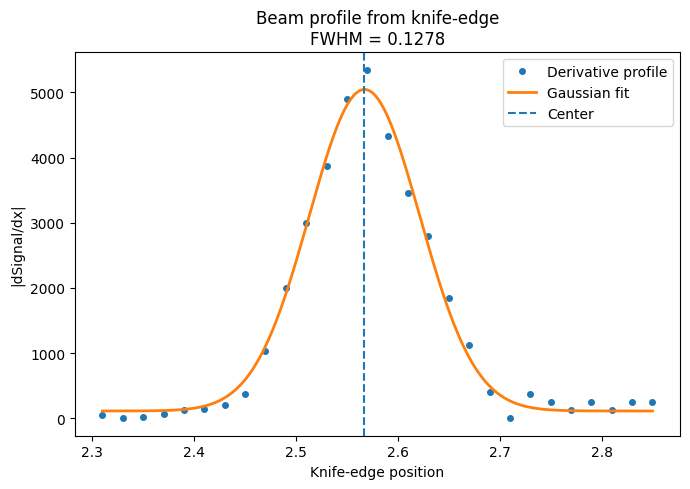

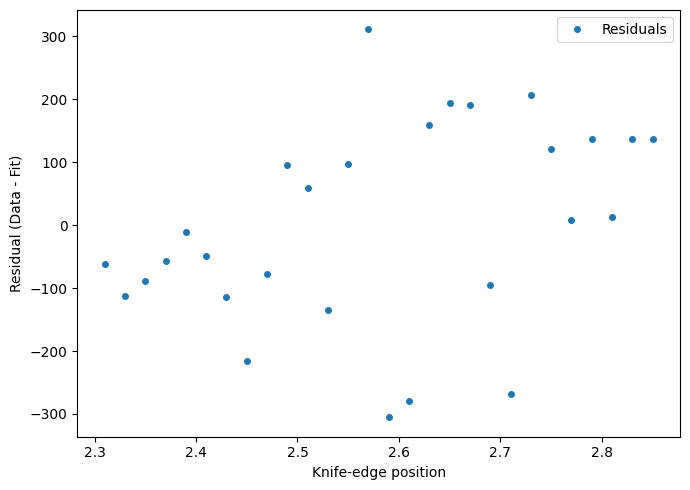

In [ ]:
analyze_knife_edge(r"C:\Users\26250\Downloads\515 pump knife edge scan (1).xlsx", columns="A:B", start_row=235, end_row=262)

===== Gaussian Fit Result =====
Amplitude A = 5724.29 +/- 60
Center x0   = 53.2131 +/- 0.00057
Sigma       = 0.0491399 +/- 0.00063
Offset      = 22.6691 +/- 22
FWHM        = 0.115716 +/- 0.0015
R^2 = 0.9974


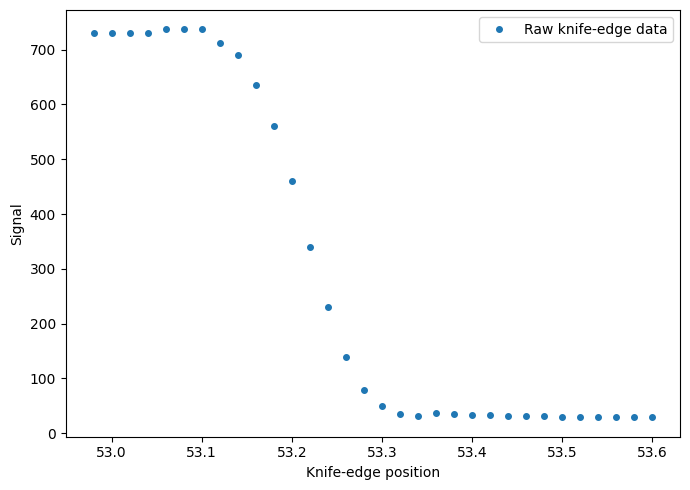

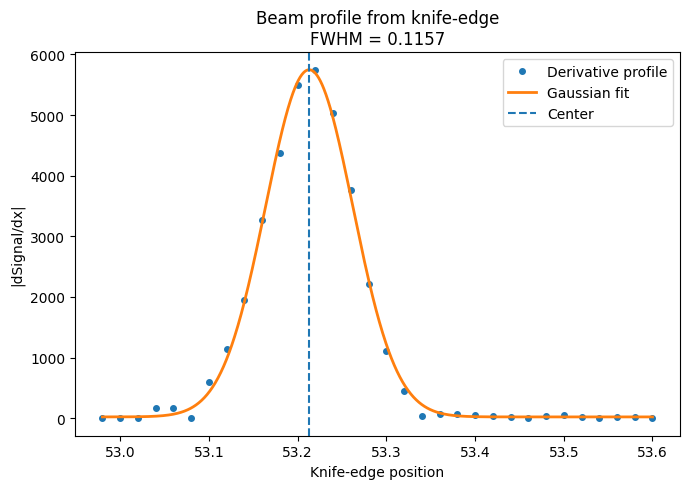

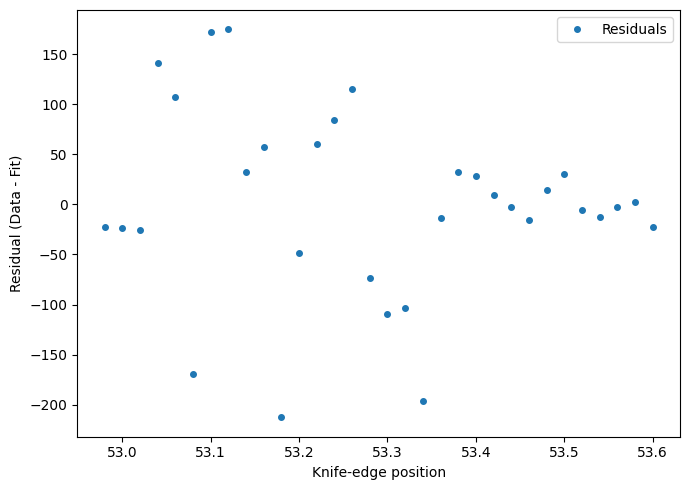

In [ ]:
analyze_knife_edge(r"C:\Users\26250\Downloads\515 pump knife edge scan (1).xlsx", columns="D:E", start_row=214, end_row=245)

===== Gaussian Fit Result =====
Amplitude A = 20.8859 +/- 0.32
Center x0   = 2.44536 +/- 0.0017
Sigma       = 0.0985976 +/- 0.0019
Offset      = 0.143517 +/- 0.11
FWHM        = 0.23218 +/- 0.0044
R^2 = 0.9951


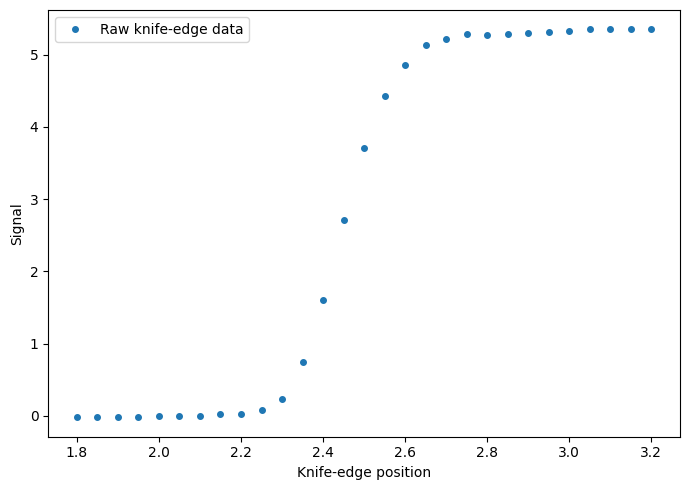

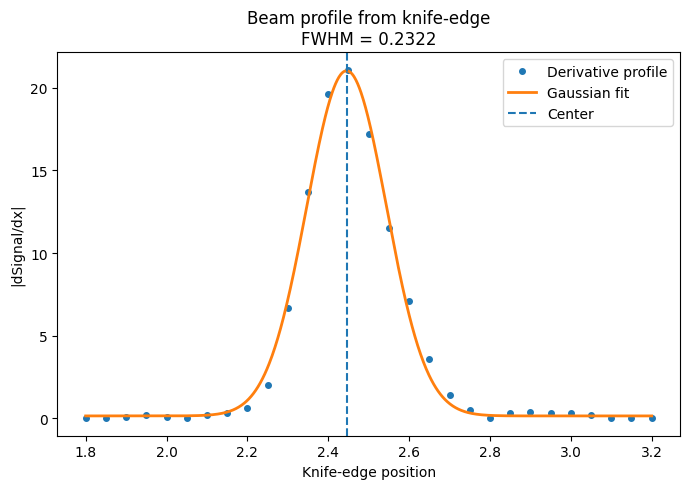

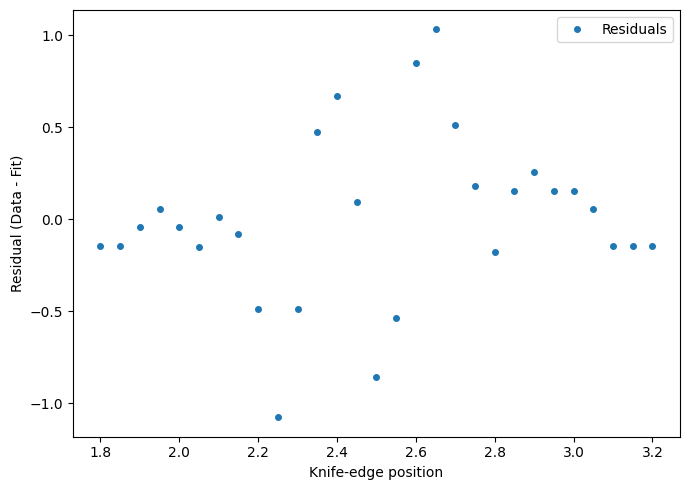

In [ ]:
analyze_knife_edge(r"C:\Users\26250\Downloads\515 pump knife edge scan (1).xlsx", columns="A:B", start_row=115, end_row=143)

===== Gaussian Fit Result =====
Amplitude A = 19.6216 +/- 0.24
Center x0   = 54.6855 +/- 0.0014
Sigma       = 0.107242 +/- 0.0016
Offset      = 0.0796528 +/- 0.077
FWHM        = 0.252535 +/- 0.0037
R^2 = 0.9965


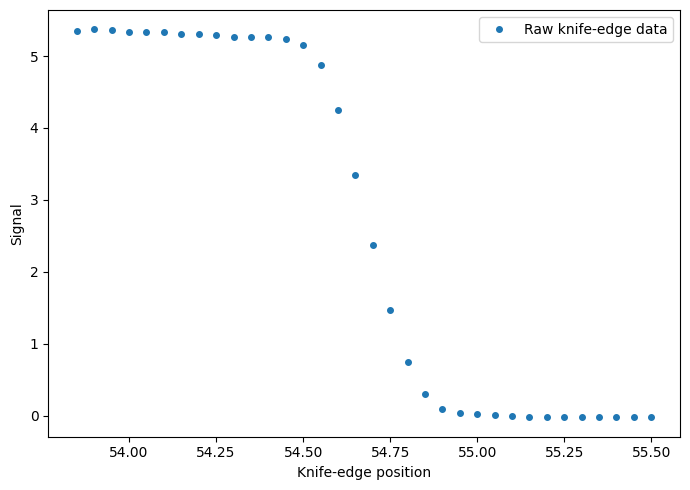

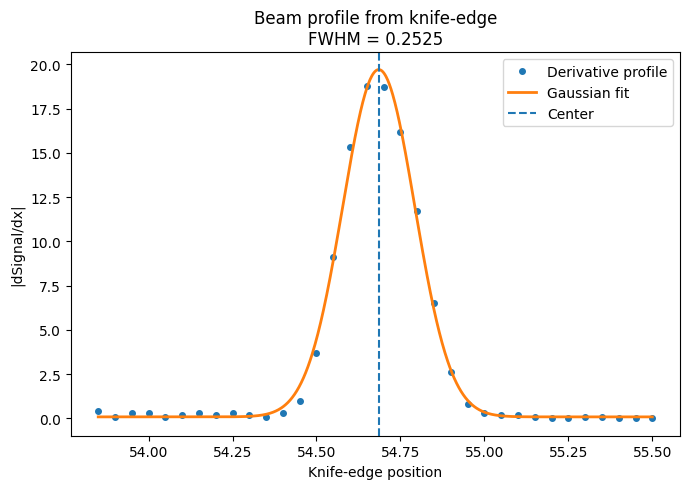

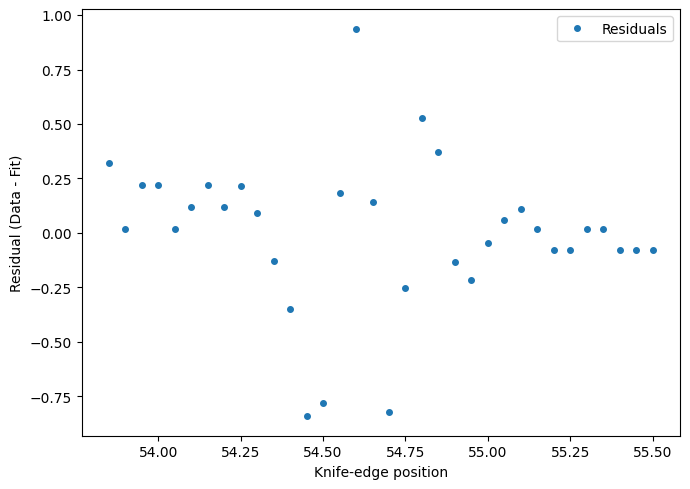

In [ ]:
analyze_knife_edge(r"C:\Users\26250\Downloads\515 pump knife edge scan (1).xlsx", columns="D:E", start_row=115, end_row=148)

===== Gaussian Fit Result =====
Amplitude A = 4411.96 +/- 95
Center x0   = 53.3314 +/- 0.0014
Sigma       = 0.0606687 +/- 0.0016
Offset      = 109.581 +/- 39
FWHM        = 0.142864 +/- 0.0038
R^2 = 0.9876


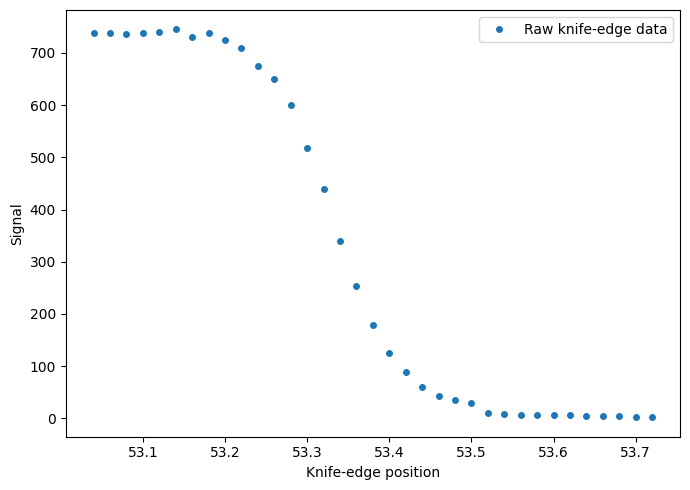

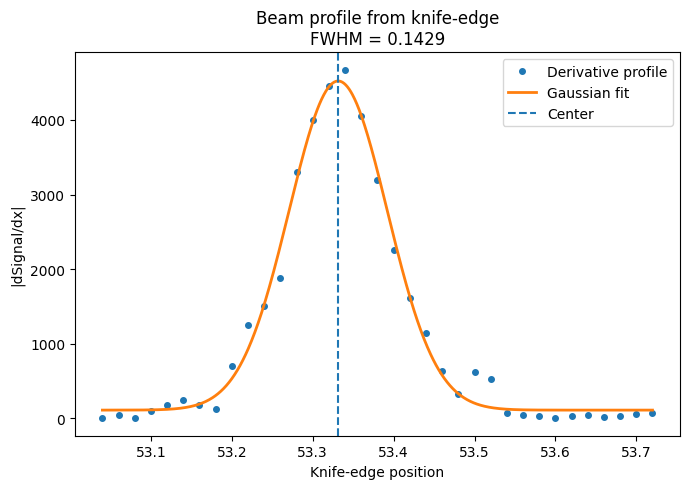

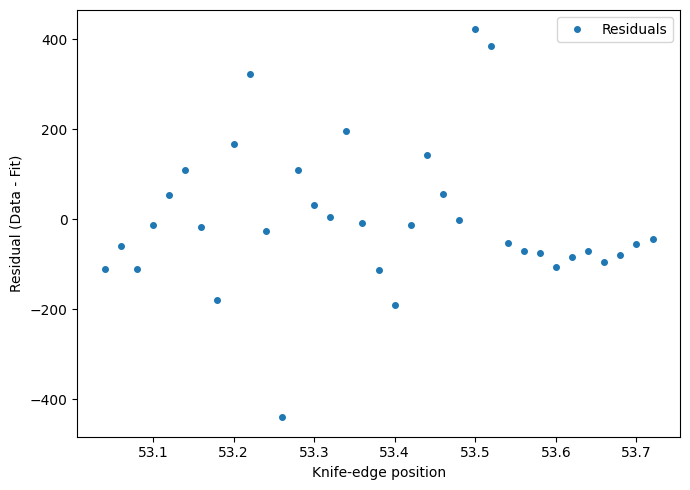

In [ ]:
analyze_knife_edge(r"C:\Users\26250\Downloads\515 pump knife edge scan (2).xlsx", columns="D:E", start_row=268, end_row=302)

===== Erf Fit Result =====
Offset      = 0.0235185 +/- 0.00013
Height      = -0.0228099 +/- 0.00019
Center x0   = 2.50911 +/- 0.0032
Sigma       = 0.127594 +/- 0.0043
FWHM        = 0.30046 +/- 0.01
R^2 = 0.9987


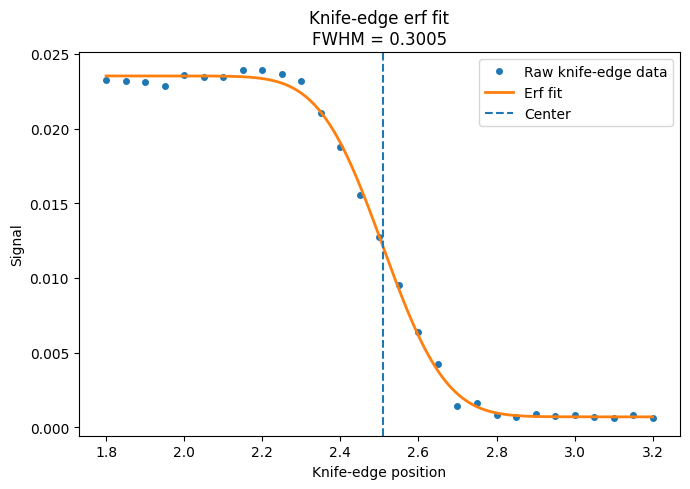

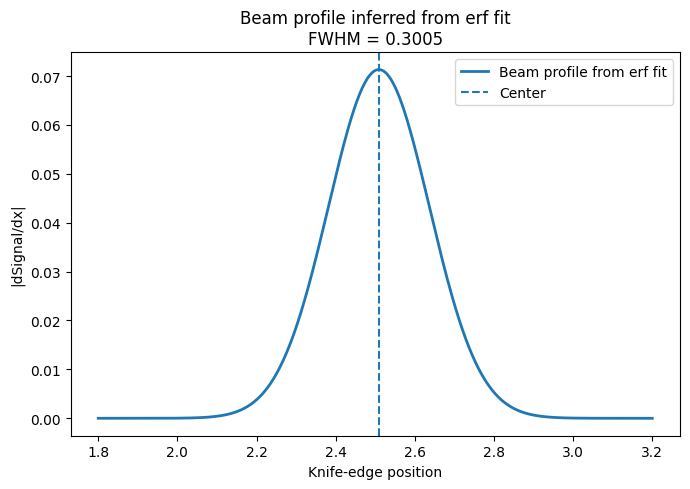

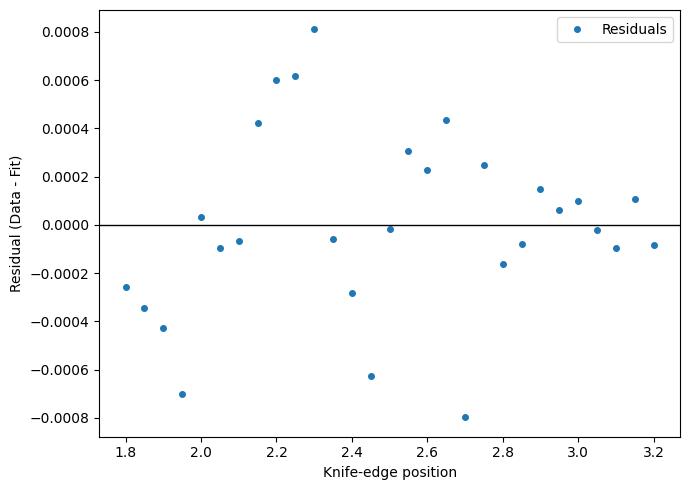

{'offset': np.float64(0.02351854206548618),
 'height': np.float64(-0.02280988131018502),
 'center': np.float64(2.5091095046871525),
 'sigma': np.float64(0.1275936915131268),
 'fwhm': np.float64(0.3004601823946063),
 'r_squared': np.float64(0.9986611719802038)}

In [ ]:
analyze_knife_edge_erf(r"C:\Users\26250\Downloads\SigScan1986.txt",x_column="X", signal_column="Photocurrent")

===== Erf Fit Result =====
Offset      = 0.00067229 +/- 9.8e-05
Height      = 0.0196129 +/- 0.00013
Center x0   = 54.4774 +/- 0.0053
Sigma       = 0.303851 +/- 0.0071
FWHM        = 0.715514 +/- 0.017
R^2 = 0.9984


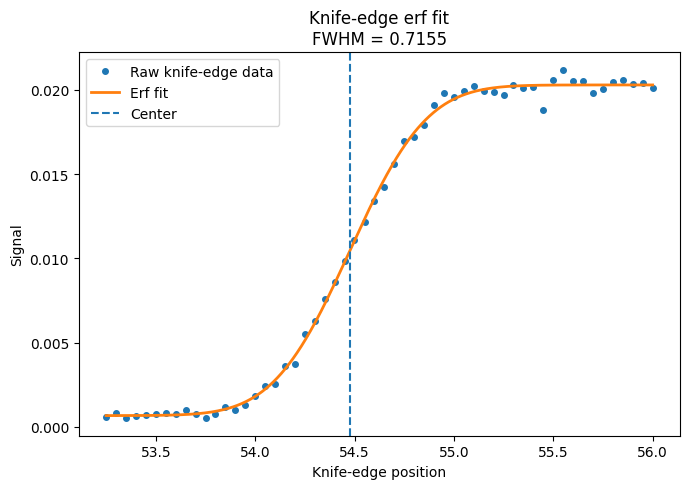

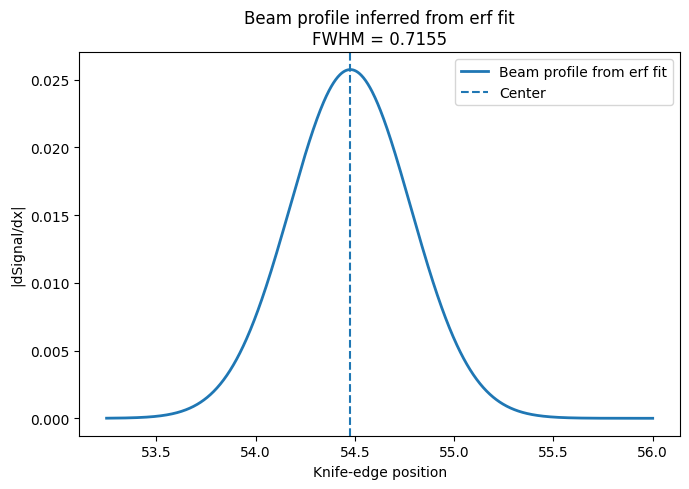

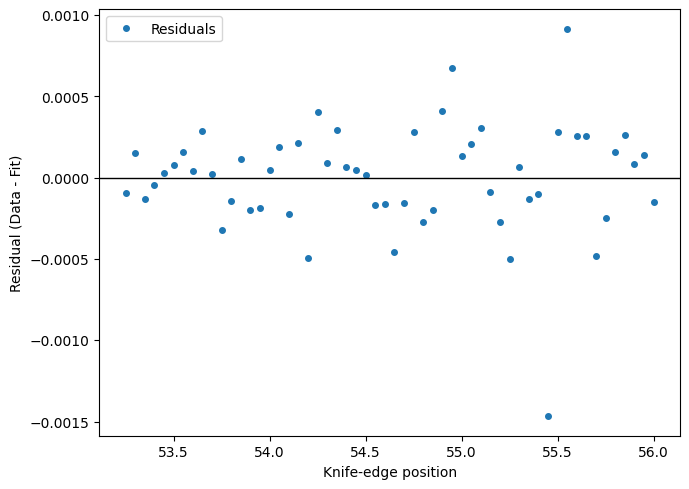

{'offset': np.float64(0.0006722899429033295),
 'height': np.float64(0.019612912102689315),
 'center': np.float64(54.47740327863521),
 'sigma': np.float64(0.3038509462457918),
 'fwhm': np.float64(0.715514298921212),
 'r_squared': np.float64(0.9984329993295656)}

In [ ]:
analyze_knife_edge_erf(r"C:\Users\26250\Downloads\SigScan1989.txt", x_column="Z", signal_column="Photocurrent")

===== Erf Fit Result =====
Offset      = -0.215302 +/- 0.06
Height      = 22.0194 +/- 0.088
Center x0   = 2.07888 +/- 0.0028
Sigma       = 0.347787 +/- 0.0039
FWHM        = 0.818975 +/- 0.0091
R^2 = 0.9997


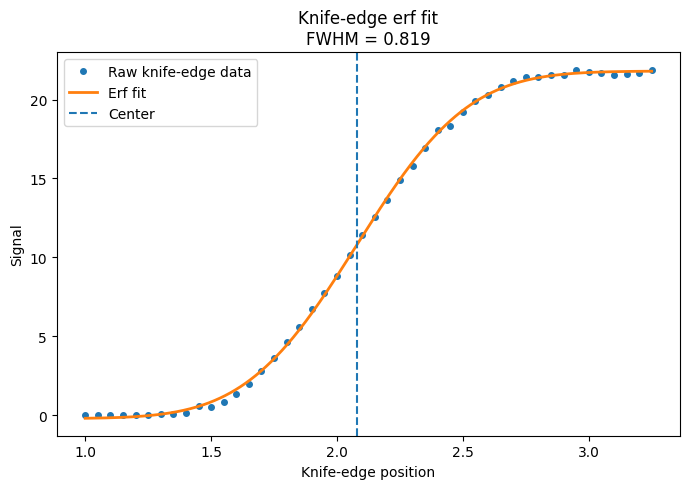

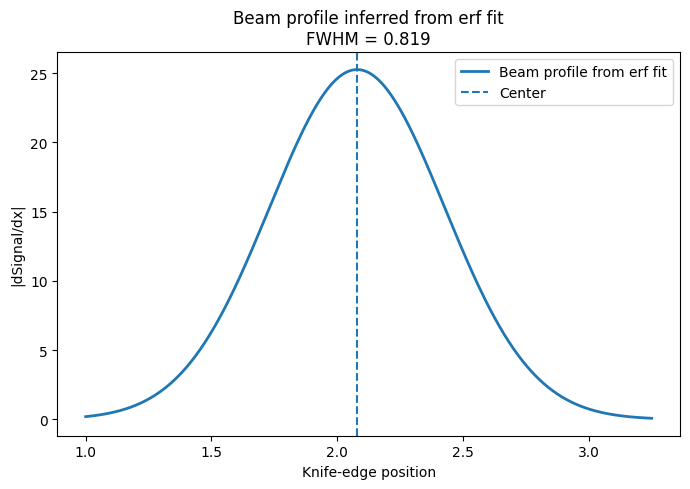

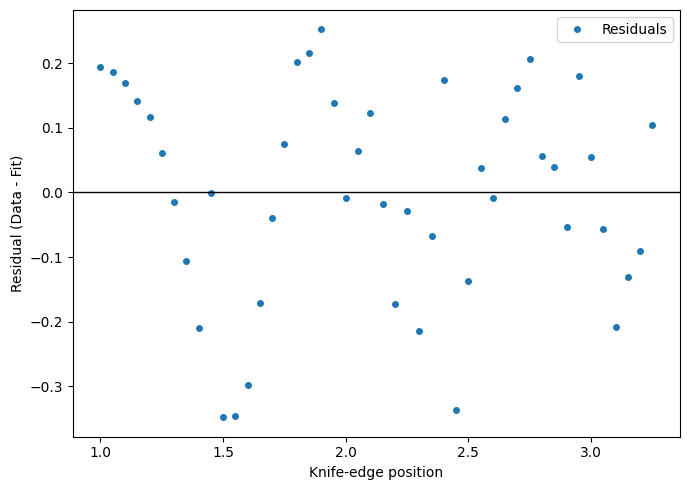

{'offset': np.float64(-0.2153018762684207),
 'height': np.float64(22.019419002689055),
 'center': np.float64(2.078877305180091),
 'sigma': np.float64(0.34778685767291173),
 'fwhm': np.float64(0.8189754638464983),
 'r_squared': np.float64(0.9996725860281072)}

In [ ]:
analyze_knife_edge_erf(r"C:\Users\26250\Downloads\pump knife edge scan.xlsx", sheet_name="1030nm", columns="A:B", start_row=5, end_row=50)

===== Erf Fit Result =====
Offset      = 0.0700882 +/- 0.00093
Height      = -0.0691043 +/- 0.0014
Center x0   = 1.81727 +/- 0.016
Sigma       = 0.216281 +/- 0.022
FWHM        = 0.509304 +/- 0.051
R^2 = 0.9777


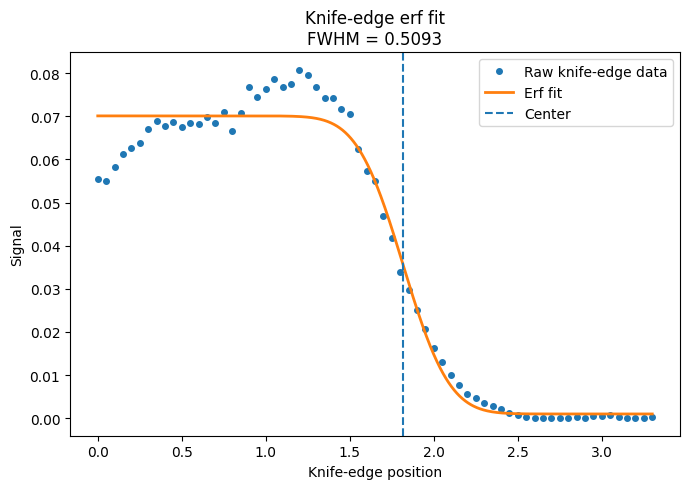

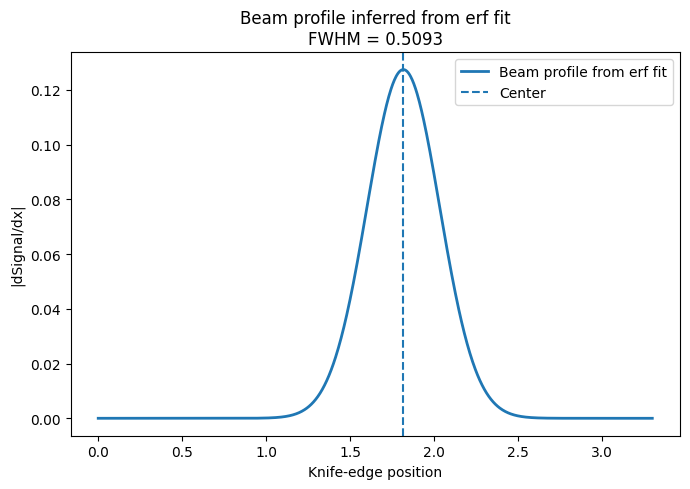

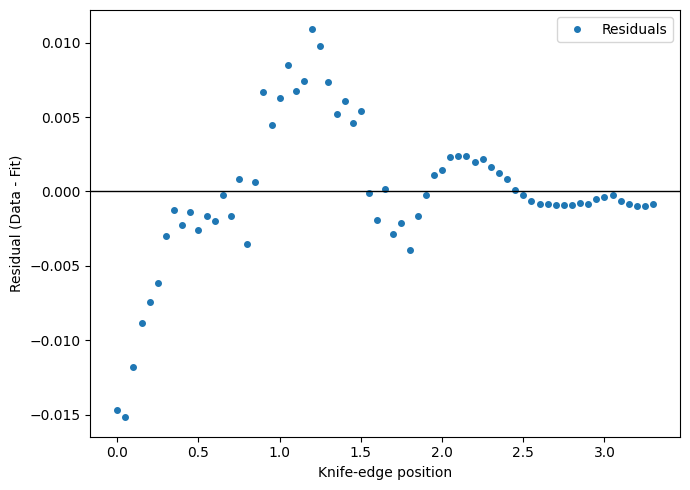

{'offset': np.float64(0.07008818361317493),
 'height': np.float64(-0.06910434187593974),
 'center': np.float64(1.817273601163498),
 'sigma': np.float64(0.21628146079875207),
 'fwhm': np.float64(0.5093039192574769),
 'r_squared': np.float64(0.9776674428357819)}

In [ ]:
analyze_knife_edge_erf(r"C:\Users\26250\Downloads\SigScan2012.txt", x_column="X", signal_column="Photocurrent")

===== Erf Fit Result =====
Offset      = 22.1586 +/- 0.048
Height      = -22.1095 +/- 0.068
Center x0   = 50.5537 +/- 0.0026
Sigma       = 0.366235 +/- 0.0035
FWHM        = 0.862418 +/- 0.0082
R^2 = 0.9997


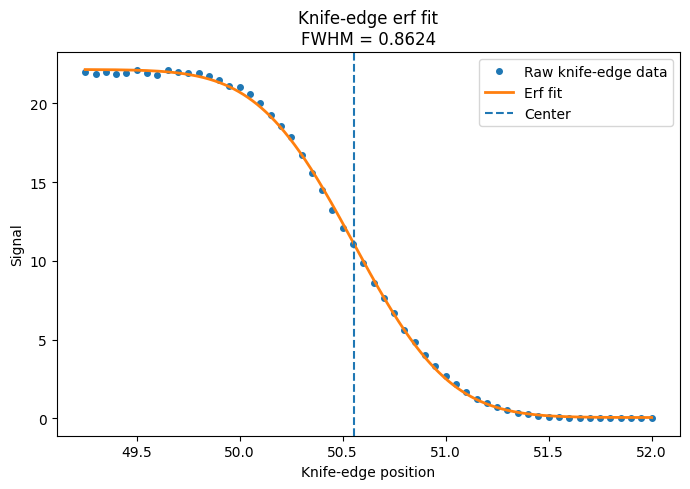

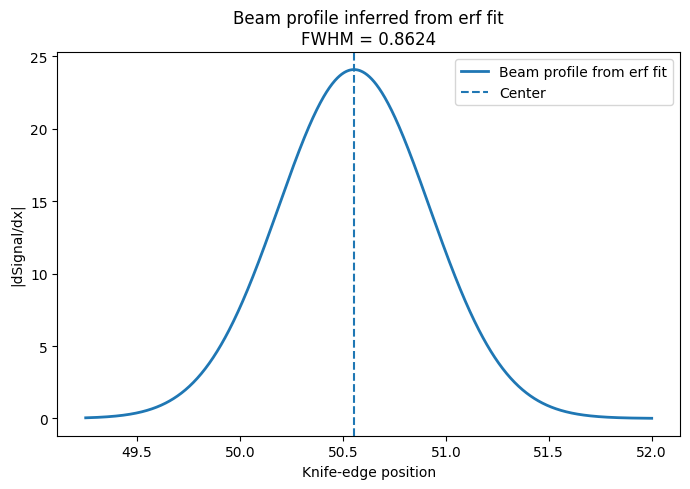

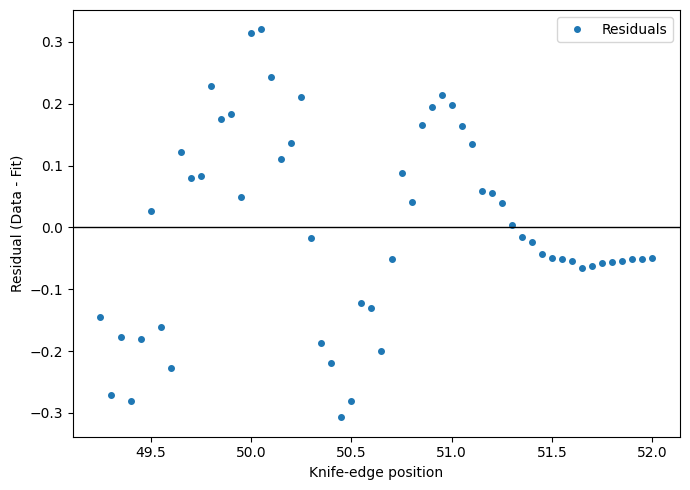

{'offset': np.float64(22.158639686023392),
 'height': np.float64(-22.109505268451073),
 'center': np.float64(50.55365013601554),
 'sigma': np.float64(0.36623511823208194),
 'fwhm': np.float64(0.8624177976071863),
 'r_squared': np.float64(0.9997130418145775)}

In [ ]:
analyze_knife_edge_erf(r"C:\Users\26250\Downloads\pump knife edge scan.xlsx", sheet_name="1030nm", columns="D:E", start_row=5, end_row=60)

===== Erf Fit Result =====
Offset      = 0.000336525 +/- 0.00052
Height      = 0.045556 +/- 0.00079
Center x0   = 50.9169 +/- 0.014
Sigma       = 0.32566 +/- 0.018
FWHM        = 0.766871 +/- 0.043
R^2 = 0.9909


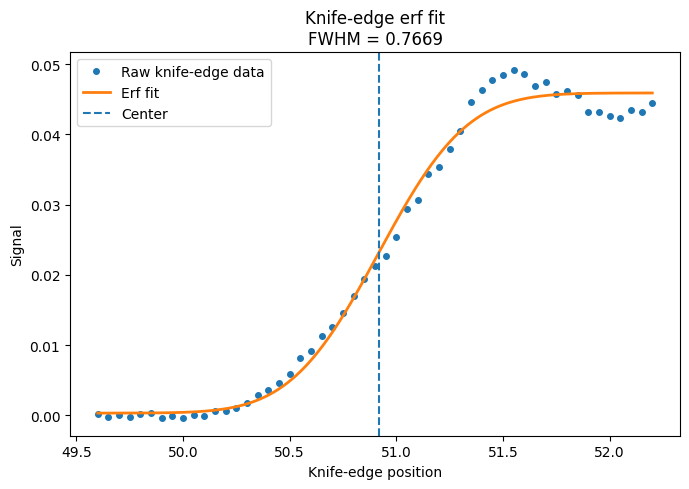

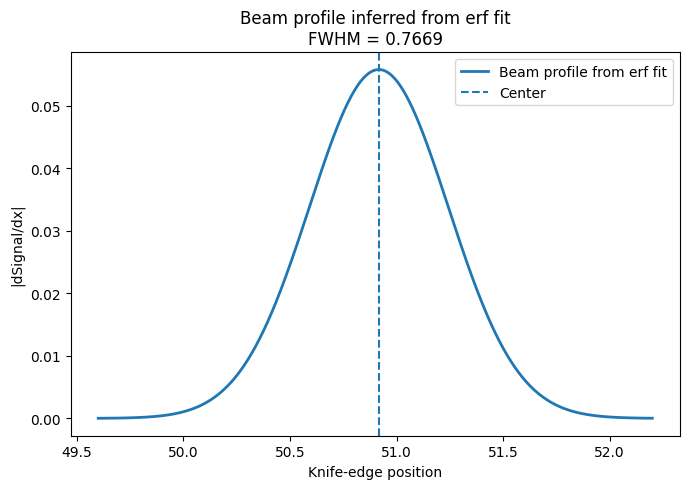

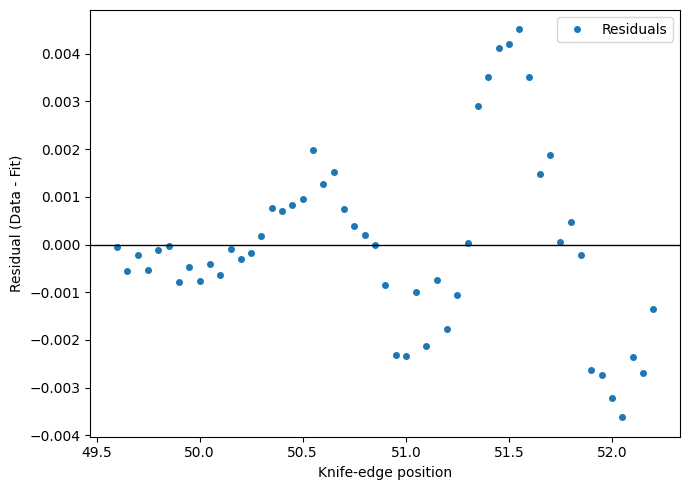

{'offset': np.float64(0.0003365251163876543),
 'height': np.float64(0.04555600211381969),
 'center': np.float64(50.91690325574827),
 'sigma': np.float64(0.32566027592133817),
 'fwhm': np.float64(0.7668713456098769),
 'r_squared': np.float64(0.9908940596823221)}

In [ ]:
analyze_knife_edge_erf(r"C:\Users\26250\Downloads\SigScan2015.txt", x_column="Z", signal_column="Photocurrent")

===== Erf Fit Result =====
Offset      = 0.00765623 +/- 0.0058
Height      = 5.60203 +/- 0.0094
Center x0   = 4.17367 +/- 0.00058
Sigma       = 0.109648 +/- 0.00078
FWHM        = 0.258202 +/- 0.0018
R^2 = 0.9999


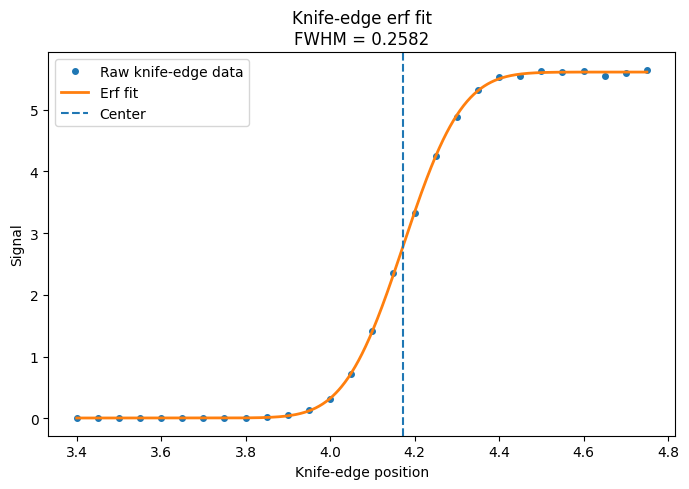

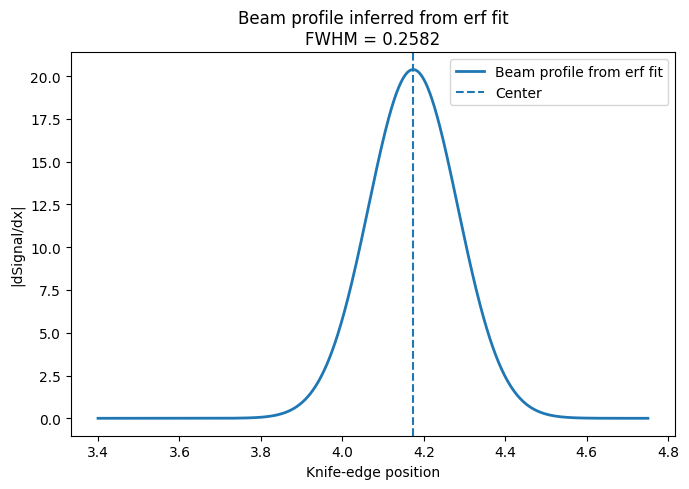

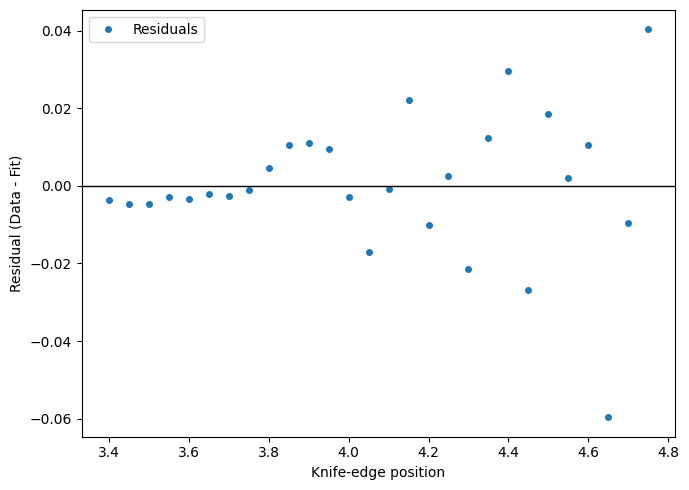

{'offset': np.float64(0.007656233679457323),
 'height': np.float64(5.602026305150359),
 'center': np.float64(4.173671821896),
 'sigma': np.float64(0.1096484659076265),
 'fwhm': np.float64(0.25820240542617157),
 'r_squared': np.float64(0.9999474393402988)}

In [ ]:
analyze_knife_edge_erf(r"C:\Users\26250\Downloads\pump knife edge scan (1).xlsx", sheet_name="1030nm", columns="A:B", start_row=117, end_row=144)

===== Erf Fit Result =====
Offset      = 5.55249 +/- 0.03
Height      = -5.52979 +/- 0.04
Center x0   = 50.628 +/- 0.0027
Sigma       = 0.141548 +/- 0.0037
FWHM        = 0.333321 +/- 0.0086
R^2 = 0.9992


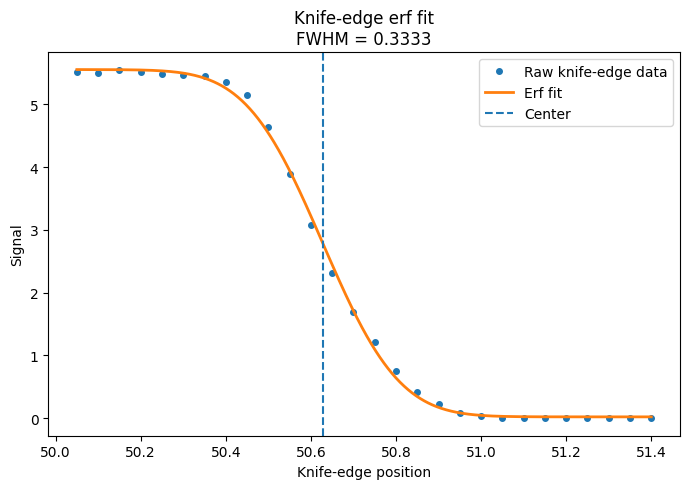

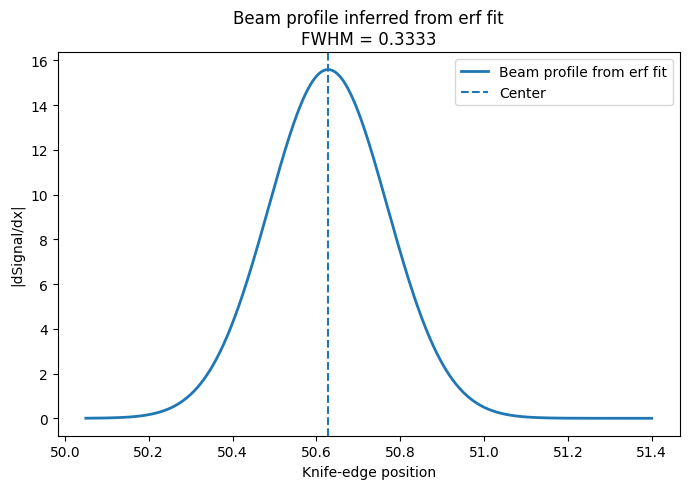

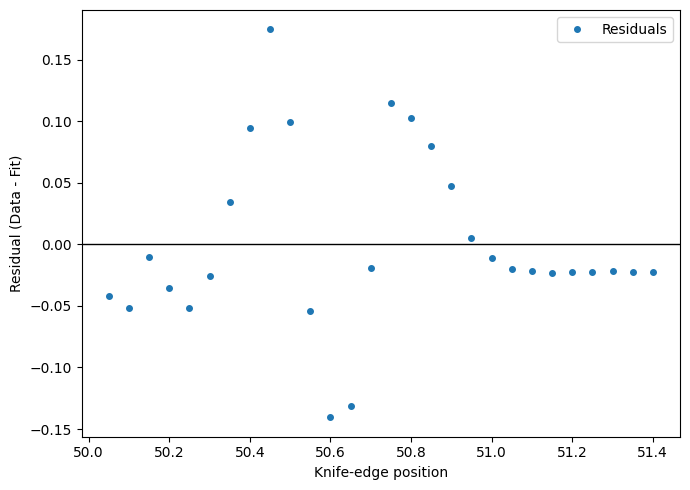

{'offset': np.float64(5.552490353894077),
 'height': np.float64(-5.529794577740704),
 'center': np.float64(50.62795628127444),
 'sigma': np.float64(0.14154828242794115),
 'fwhm': np.float64(0.3333207328010179),
 'r_squared': np.float64(0.9991549140679794)}

In [ ]:
analyze_knife_edge_erf(r"C:\Users\26250\Downloads\pump knife edge scan (1).xlsx", sheet_name="1030nm", columns="D:E", start_row=117, end_row=144)

===== Erf Fit Result =====
Offset      = -0.12289 +/- 0.047
Height      = 14.6393 +/- 0.071
Center x0   = 2.05177 +/- 0.003
Sigma       = 0.258127 +/- 0.0041
FWHM        = 0.607843 +/- 0.0096
R^2 = 0.9994


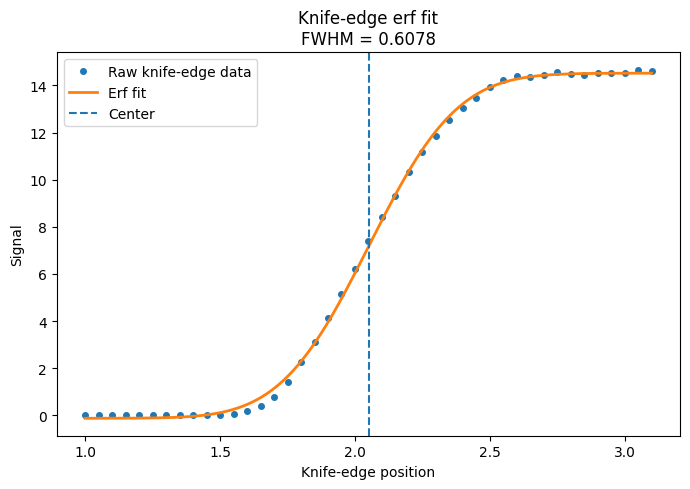

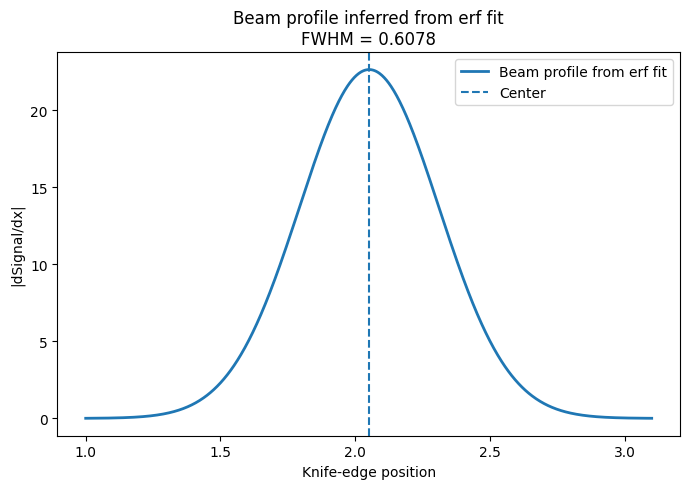

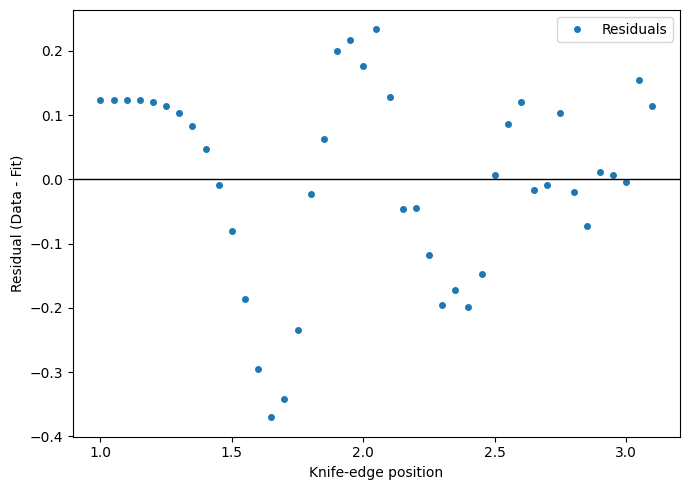

{'offset': np.float64(-0.12289036347660993),
 'height': np.float64(14.639335289891621),
 'center': np.float64(2.051772412953866),
 'sigma': np.float64(0.25812708474036494),
 'fwhm': np.float64(0.6078428333120138),
 'r_squared': np.float64(0.9994276214995288)}

In [4]:
analyze_knife_edge_erf(r"C:\Users\26250\Downloads\pump knife edge scan (1).xlsx", sheet_name="1030nm", columns="A:B", start_row=66, end_row=108)

===== Erf Fit Result =====
Offset      = 18.9999 +/- 0.095
Height      = -18.9582 +/- 0.11
Center x0   = 50.5345 +/- 0.0036
Sigma       = 0.268845 +/- 0.0048
FWHM        = 0.633082 +/- 0.011
R^2 = 0.9992


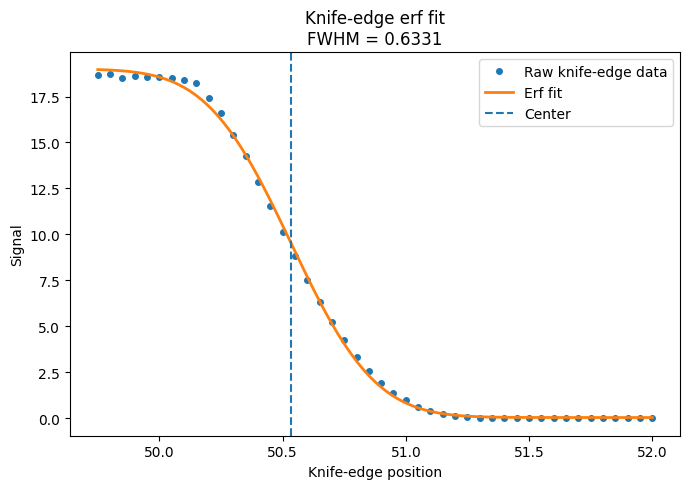

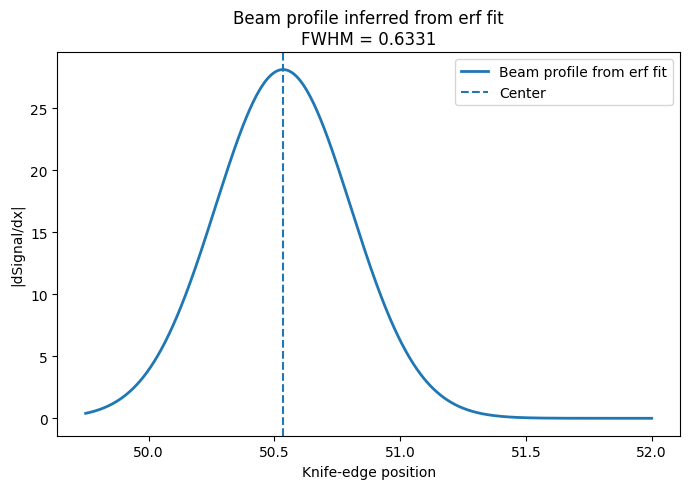

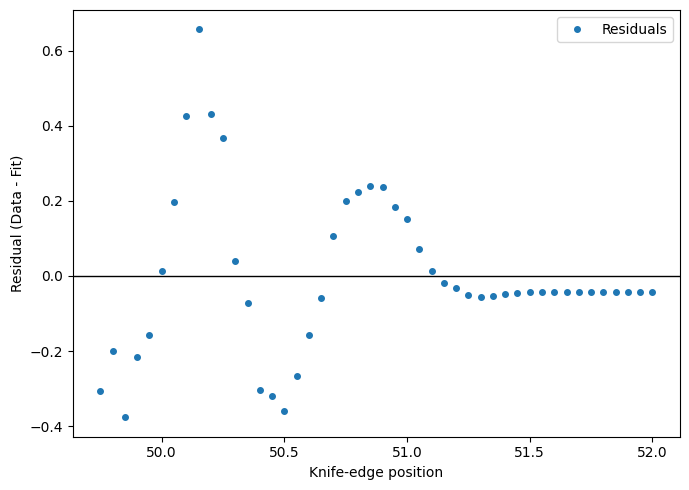

{'offset': np.float64(18.999911776606478),
 'height': np.float64(-18.958226120112247),
 'center': np.float64(50.534530206720845),
 'sigma': np.float64(0.2688451470439997),
 'fwhm': np.float64(0.6330819412685036),
 'r_squared': np.float64(0.9992317548804126)}

In [5]:
analyze_knife_edge_erf(r"C:\Users\26250\Downloads\pump knife edge scan (1).xlsx", sheet_name="1030nm", columns="D:E", start_row=66, end_row=111)

===== Erf Fit Result =====
Offset      = 26.8083 +/- 10
Height      = 4547.31 +/- 15
Center x0   = 3.16373 +/- 0.00094
Sigma       = 0.0751846 +/- 0.0013
FWHM        = 0.177046 +/- 0.003
R^2 = 0.9998


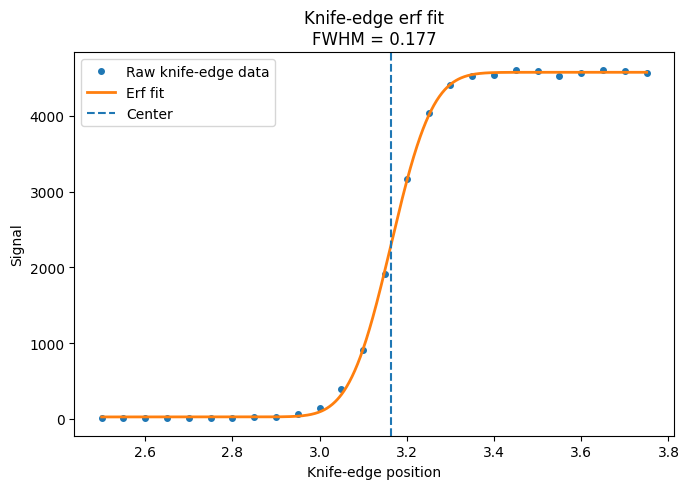

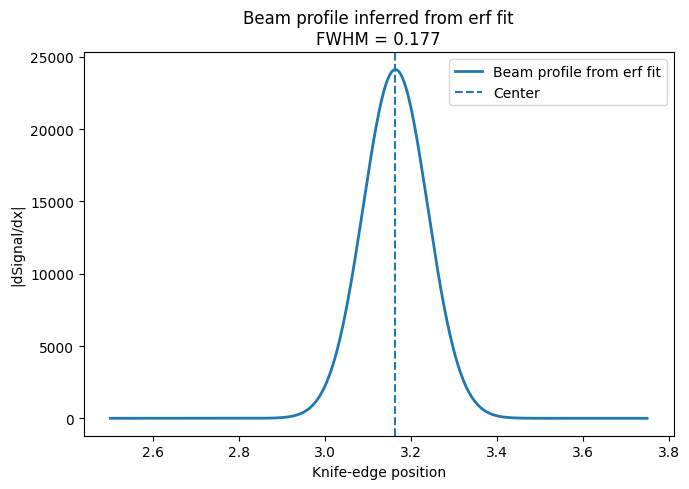

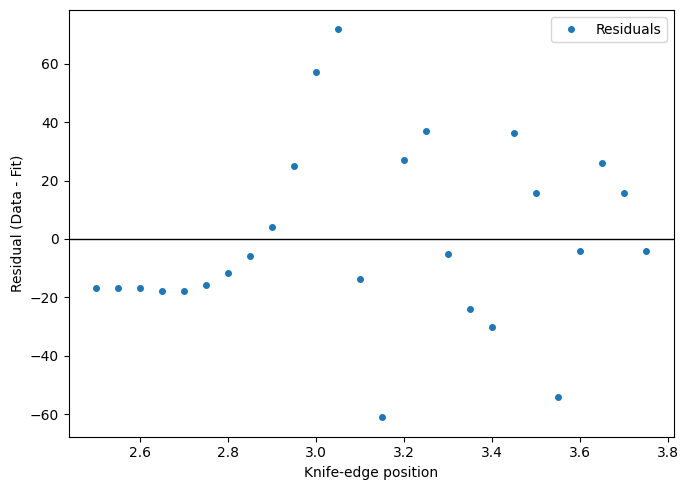

{'offset': np.float64(26.80827950767902),
 'height': np.float64(4547.3106037685075),
 'center': np.float64(3.163726770816932),
 'sigma': np.float64(0.07518457785187772),
 'fwhm': np.float64(0.1770461510027916),
 'r_squared': np.float64(0.9997940713363356)}

In [3]:
analyze_knife_edge_erf(r"C:\Users\26250\Downloads\pump knife edge scan (2).xlsx", sheet_name="1030nm", columns="A:B", start_row=153, end_row=178)

===== Erf Fit Result =====
Offset      = 4574.63 +/- 12
Height      = -4562.47 +/- 16
Center x0   = 54.2834 +/- 0.0011
Sigma       = 0.103561 +/- 0.0016
FWHM        = 0.243869 +/- 0.0037
R^2 = 0.9998


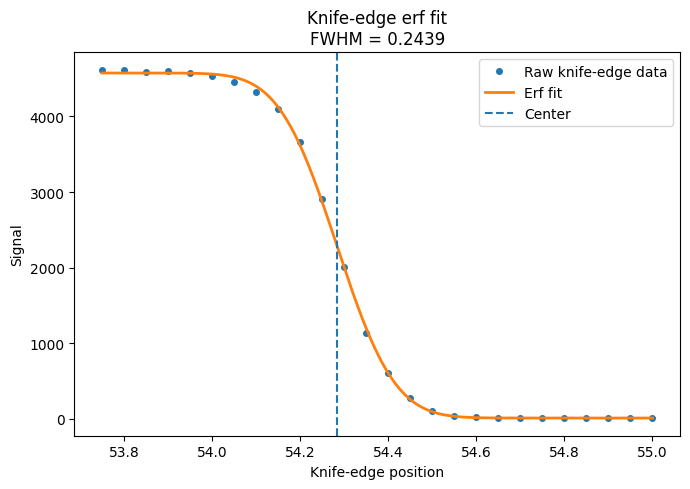

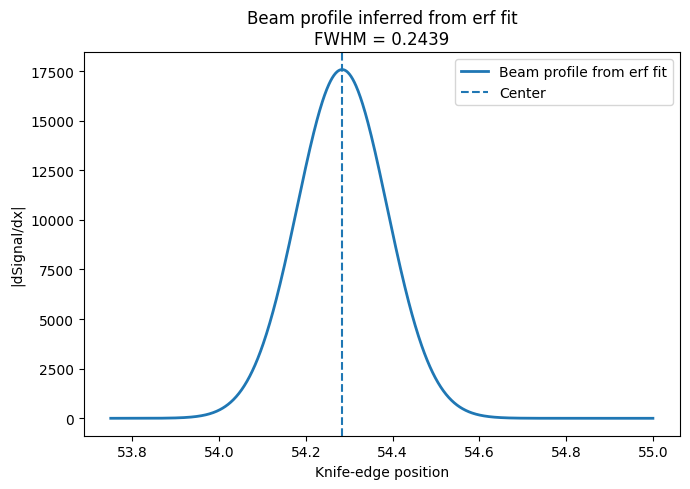

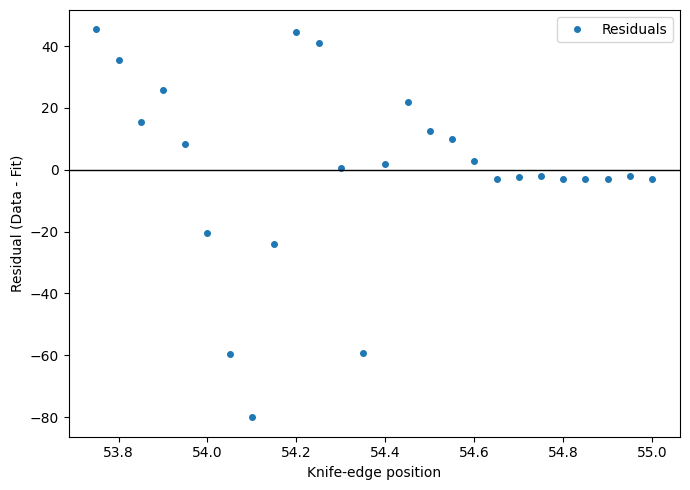

{'offset': np.float64(4574.625576917753),
 'height': np.float64(-4562.470029337101),
 'center': np.float64(54.28343605977392),
 'sigma': np.float64(0.10356144744538064),
 'fwhm': np.float64(0.2438685723368015),
 'r_squared': np.float64(0.9997856954758445)}

In [4]:
analyze_knife_edge_erf(r"C:\Users\26250\Downloads\pump knife edge scan (2).xlsx", sheet_name="1030nm", columns="D:E", start_row=153, end_row=178)

===== Erf Fit Result =====
Offset      = 9.3769 +/- 7.7
Height      = 3293.05 +/- 12
Center x0   = 3.17041 +/- 0.00099
Sigma       = 0.075124 +/- 0.0014
FWHM        = 0.176903 +/- 0.0032
R^2 = 0.9998


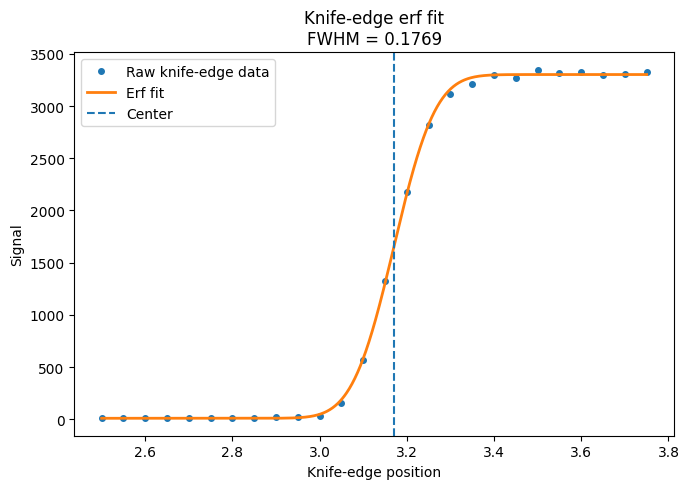

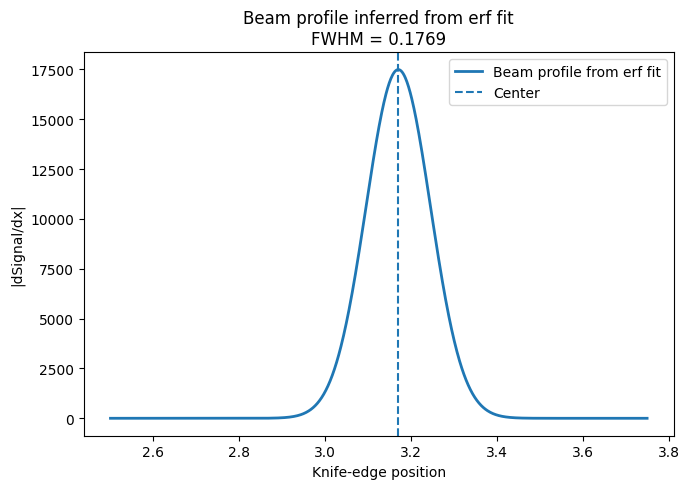

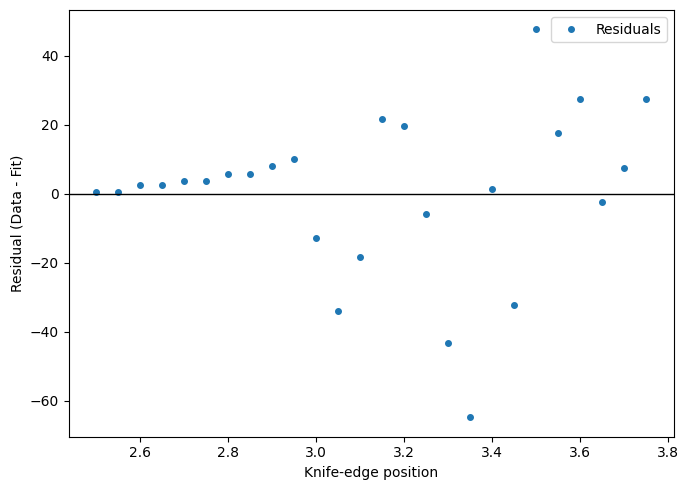

{'offset': np.float64(9.376901222008598),
 'height': np.float64(3293.050757585862),
 'center': np.float64(3.1704056052986953),
 'sigma': np.float64(0.07512396102356833),
 'fwhm': np.float64(0.17690340928042245),
 'r_squared': np.float64(0.9997693751359558)}

In [5]:
analyze_knife_edge_erf(r"C:\Users\26250\Downloads\pump knife edge scan (3).xlsx", sheet_name="1030nm", columns="A:B", start_row=185, end_row=210)

===== Erf Fit Result =====
Offset      = 3294.9 +/- 5
Height      = -3277.5 +/- 7.1
Center x0   = 54.3591 +/- 0.00059
Sigma       = 0.067877 +/- 0.0008
FWHM        = 0.159838 +/- 0.0019
R^2 = 0.9999


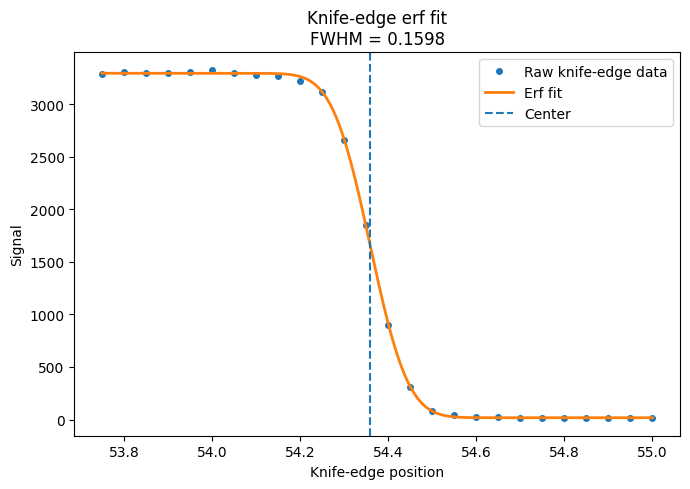

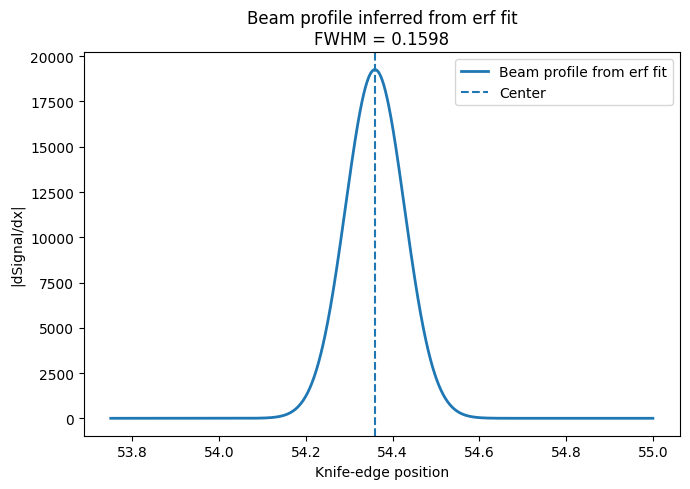

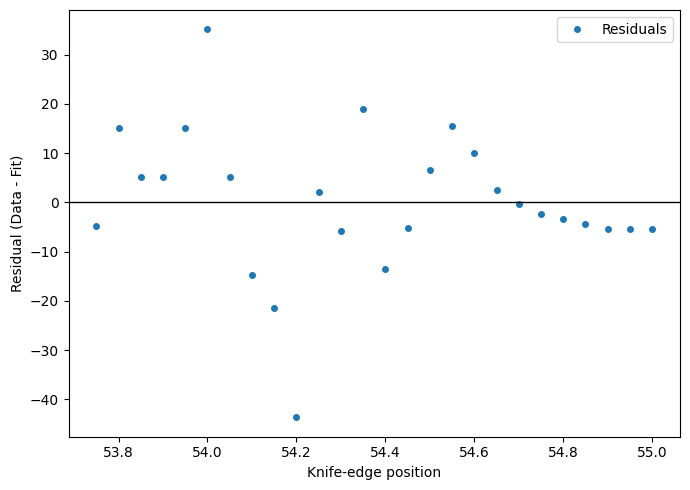

{'offset': np.float64(3294.9014129691323),
 'height': np.float64(-3277.5037852074956),
 'center': np.float64(54.35910547175866),
 'sigma': np.float64(0.06787701990547348),
 'fwhm': np.float64(0.1598381670703737),
 'r_squared': np.float64(0.9999107250139317)}

In [6]:
analyze_knife_edge_erf(r"C:\Users\26250\Downloads\pump knife edge scan (3).xlsx", sheet_name="1030nm", columns="D:E", start_row=185, end_row=210)